<a href="https://colab.research.google.com/github/harshithaselvaraj07/Credit_Card/blob/main/Credit_Card.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gradio joblib seaborn


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving det.csv to det.csv


In [ ]:
import pandas as pd
import numpy as np

data = pd.read_csv("det.csv")

data.replace('na', np.nan, inplace=True)
data.dropna(inplace=True)
data.drop_duplicates(inplace=True)

data['Time'] = data['Time'].abs()
data['Amount'] = data['Amount'].abs()

data.head()



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,1.996823,-0.701082,-0.041687,1.680101,0.976623,-0.247020,0.348012,0.193700,0.084434,0.333534,...,-0.024777,0.383483,-0.177444,0.110157,0.247059,-0.392622,0.333033,-0.065850,0.244200,-0.040864
1,1.996823,0.608792,0.164138,0.109279,0.318998,0.042258,-0.060980,-0.065656,0.072903,-0.231703,...,-0.311372,-0.881454,0.162081,-0.561503,0.321175,0.260854,-0.027154,0.043219,0.342584,-0.040864
2,1.996802,-0.700336,-0.811337,1.174270,0.270648,-0.366756,1.352655,0.643223,0.210788,-1.381169,...,0.343094,1.065068,1.457772,-1.138484,-0.628161,-0.288861,-0.144325,-0.183824,1.158900,-0.040864
3,1.996802,-0.499064,-0.109972,1.187383,-0.608355,-0.008814,0.937245,0.192079,0.320843,-1.264664,...,-0.149093,0.007299,-0.305465,-1.941446,1.242487,-0.460694,0.154039,0.185687,0.139886,-0.040864
4,1.996781,-0.597606,0.535539,1.025470,0.287092,-0.297036,0.072873,0.481517,-0.228725,0.747917,...,-0.012516,1.101780,-0.220709,0.232904,-0.394800,1.041677,0.550001,0.654234,0.073813,-0.040864


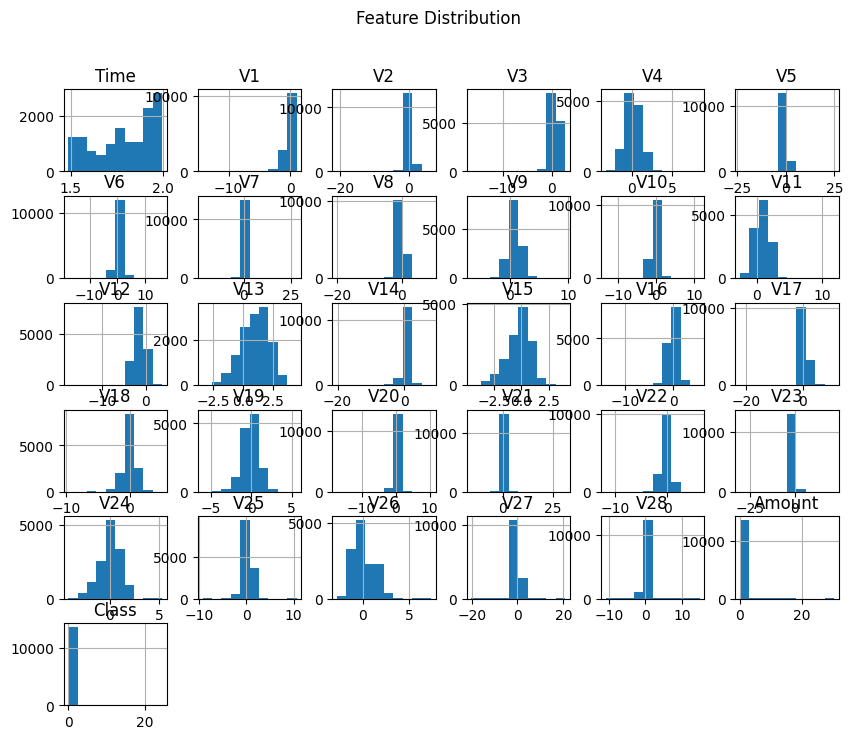

In [ ]:
data.hist(figsize=(10,8))
plt.suptitle("Feature Distribution")
plt.show()


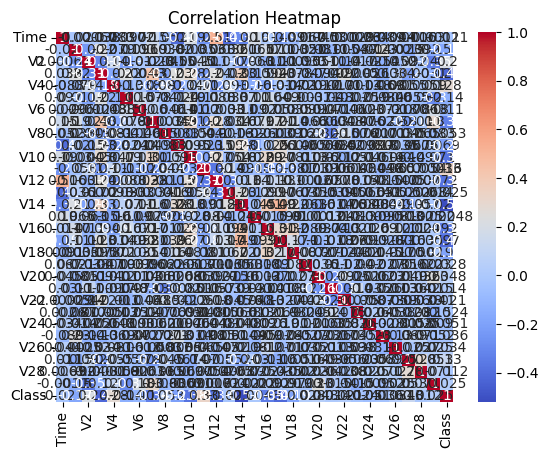

In [ ]:
sns.heatmap(
    data.corr(),
    annot=True, cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
data['amount_class'] = pd.cut(
    data['Amount'],
    bins=3,
    labels=[0,1,2]
)


In [ ]:
scaler = StandardScaler()

cols = ['Time', 'Amount']

data[cols] = scaler.fit_transform(data[cols])


In [ ]:
target = 'Class'
features = data.drop(columns=[target])

X = features
y = data[target].astype(int)   # convert target to discrete classes

selector = SelectKBest(mutual_info_classif, k=2)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
X_selected = pd.DataFrame(X_new, columns=selected_features)

print("Selected Features:", selected_features)



Selected Features: Index(['V12', 'V14'], dtype='object')


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average='weighted')
    rec = recall_score(y_test, pred, average='weighted')
    f1 = f1_score(y_test, pred, average='weighted')

    results[name] = [acc, prec, rec, f1]

results_df = pd.DataFrame(
    results,
    index=["Accuracy","Precision","Recall","F1 Score"]
).T

results_df


,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.995957,0.995409,0.995957,0.995639
Decision Tree,0.998530,0.998449,0.998530,0.998457
Random Forest,0.998530,0.998449,0.998530,0.998457
Gradient Boosting,0.998530,0.998449,0.998530,0.998457
SVM,0.998530,0.998449,0.998530,0.998457


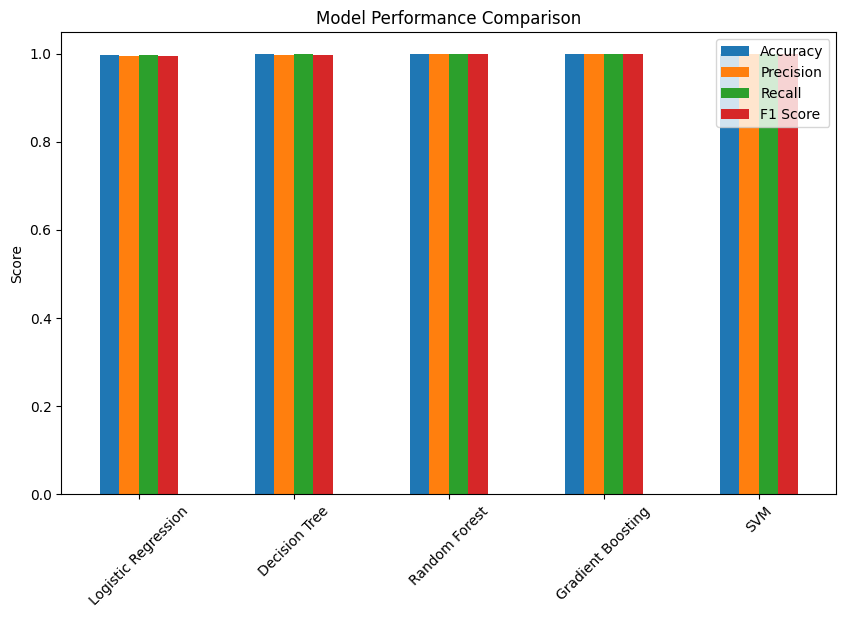

In [ ]:
results_df.plot(kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()


In [ ]:
best_model_name = results_df["F1 Score"].idxmax()
best_model = models[best_model_name]

print("Best Model:", best_model_name)


Best Model: Decision Tree


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

best_model_name = results_df["F1 Score"].idxmax()
best_model = models[best_model_name]

y_pred = best_model.predict(X_test)

if len(np.array(y_pred).shape) > 1:
    y_pred = np.argmax(y_pred, axis=1)

y_test = np.array(y_test).flatten()
y_pred = np.array(y_pred).flatten()

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

In [ ]:
support = len(y_test)

final_table = pd.DataFrame({
    "Metric":["Accuracy","Precision","Recall","F1 Score","Support"],
    "Value":[accuracy,precision,recall,f1,support]
})

final_table

,Metric,Value
0,Accuracy,0.998530
1,Precision,0.998449
2,Recall,0.998530
3,F1 Score,0.998457
4,Support,2721.000000


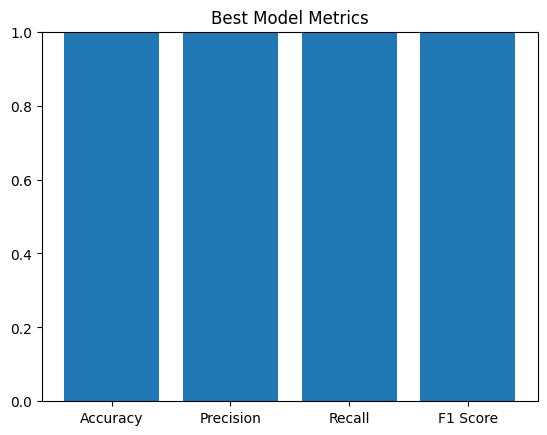

In [ ]:
metrics_plot = {
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1 Score":f1
}

plt.bar(metrics_plot.keys(), metrics_plot.values())
plt.ylim(0,1)
plt.title("Best Model Metrics")
plt.show()


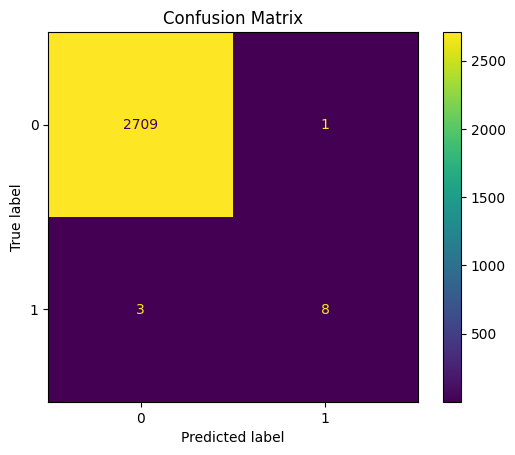

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()


In [ ]:
joblib.dump(best_model, "final_model.pkl")


['final_model.pkl']

In [ ]:
import gradio as gr
import numpy as np

def predict(*inputs):

    data = np.array([inputs])

    pred = best_model.predict(data)

    if pred[0] == 1:
        return "Fraud Transaction Detected"
    else:
        return "Normal Transaction"

interface = gr.Interface(
    fn=predict,
    inputs=[gr.Number(label=f"Feature {i+1}") for i in range(best_model.n_features_in_)],
    outputs="text",
    title="Credit Card Fraud Detection System"
)

interface.launch(share=True)